In [54]:
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy
np.random.seed(42)

In [55]:
# Linkage Metrics

In [56]:
def singleLinkage(c1, c2):
    dist = np.inf
    for e1 in c1:
        for e2 in c2:
            cur = np.linalg.norm(e1 - e2)
            if cur < dist: # dist = min(dist,cur)
                dist = cur #
    return dist

In [57]:
def completeLinkage(c1,c2):
    dist = 0
    for e1 in c1:
        for e2 in c2:
            cur = np.linalg.norm(e1 - e2)
            if cur > dist: # dist = max(dist,cur)
                dist = cur #
    return dist

In [58]:
def averageLinkage(c1,c2):
    sumDist = 0
    nofdist = len(c1) * len(c2)
    if nofdist == 0:
        return 0
    for e1 in c1:
        for e2 in c2:
            sumDist += np.linalg.norm(e1 - e2)
    return sumDist/nofdist

In [59]:
def hierarchical(points, linkage = singleLinkage):
    C = [[p] for p in points]
    numOfC = len(points)
    snapshots = []
    while numOfC > 1:
        numOfC -= 1
        closeOnes = []
        minDist = np.inf
        for l1, c1 in enumerate(C):
            for l2, c2 in enumerate(C):
                if l1 == l2:
                    break
                if l1 < l2:
                    continue 
                d = linkage(c1,c2)
                if d < minDist:
                    minDist = d
                    closeOnes = [l1,l2]
        C[closeOnes[1]].extend(C[closeOnes[0]])
        C.pop(closeOnes[0])
        snapshots.append(deepcopy(C))
    return snapshots

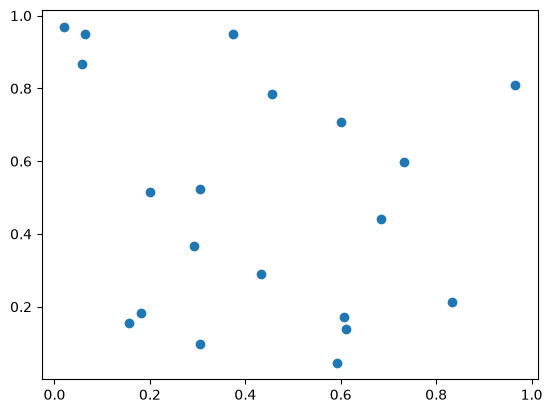

In [60]:
np.random.seed(42)
data = np.random.rand(20, 2)
plt.scatter(data[:,0], data[:,1])

In [61]:
snapshots = hierarchical(data)

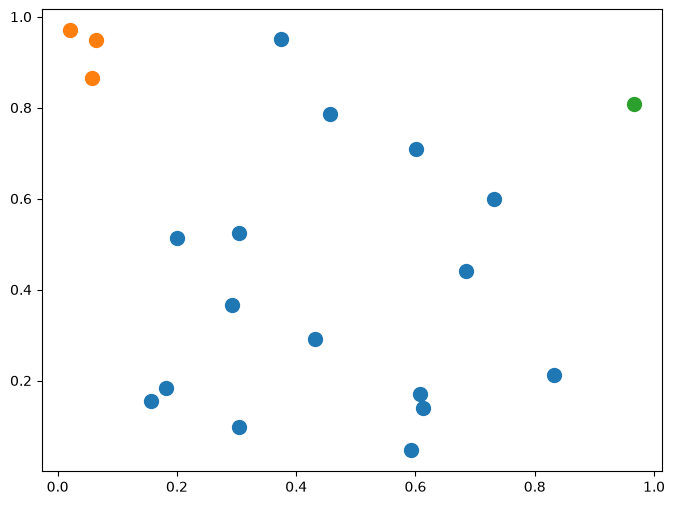

In [62]:
def plot(snapshot):
    plt.figure(figsize=(8, 6))
    for cluster in snapshot:
        pts = np.array(cluster)
        plt.scatter(pts[:, 0], pts[:, 1], s=100)
    plt.show()
plot(snapshots[-3])